<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

!pip install pandas
!pip install matplotlib 
!pip install seaborn

##### Import Necessary Modules:


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:

file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(file_path)
print(df.head())
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

df = pd.read_csv(file_path)
print(df.head()) 

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [4]:

import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

print("First 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

print("\nSummary Statistics (Including Categorical Data):")
print(df.describe(include='all'))

print("\nDataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())


print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                   

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [5]:

import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

print("\nColumns Having Missing Values:\n")
print(missing_values[missing_values > 0])

Missing Values in Each Column:

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64

Columns Having Missing Values:

RemoteWork             10635
CodingActivities       10975
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16202
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 109, dtype: int64


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



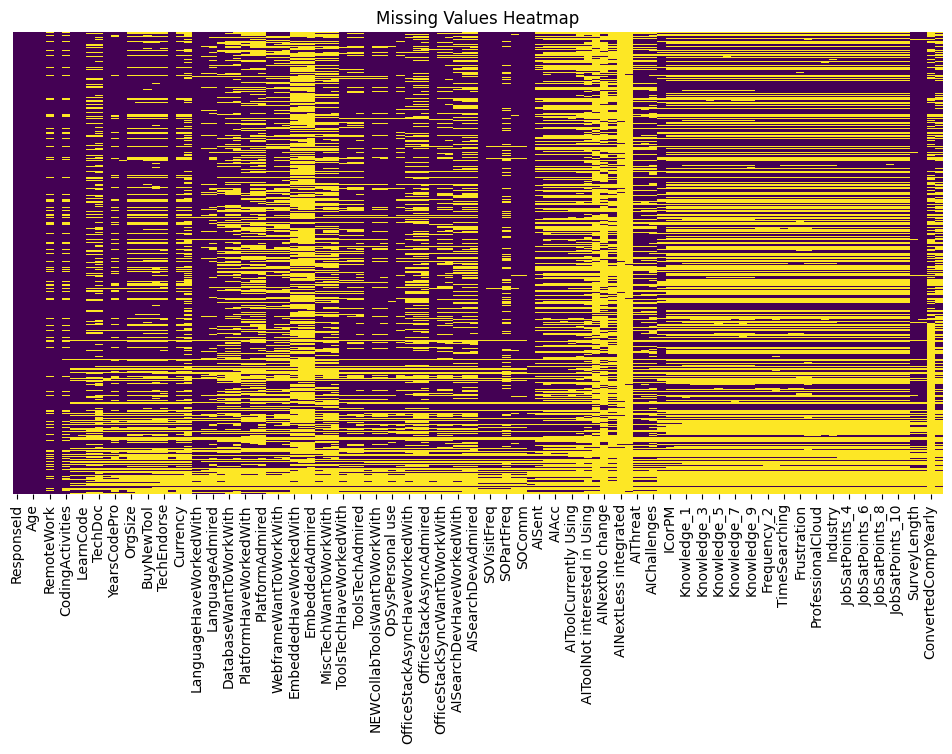

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)


plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), 
            cbar=False, 
            cmap='viridis', 
            yticklabels=False)

plt.title("Missing Values Heatmap")

plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [7]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

missing_employment = df['Employment'].isnull().sum()


print("Number of missing rows in 'Employment' column:")
print(missing_employment)

Number of missing rows in 'Employment' column:
0


### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [8]:

import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

majority_value = df['Employment'].mode()[0]

print("Most Frequent (Majority) Value in 'Employment' column:")
print(majority_value)

Most Frequent (Majority) Value in 'Employment' column:
Employed, full-time


##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [10]:
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

majority_value = df['Employment'].mode()[0]

df['Employment'] = df['Employment'].fillna(majority_value)


print("Missing values remaining in Employment column:")
print(df['Employment'].isnull().sum())

print("\nUpdated Employment Column:")
print(df['Employment'].head())

Missing values remaining in Employment column:
0

Updated Employment Column:
0    Employed, full-time
1    Employed, full-time
2    Employed, full-time
3     Student, full-time
4     Student, full-time
Name: Employment, dtype: str


### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


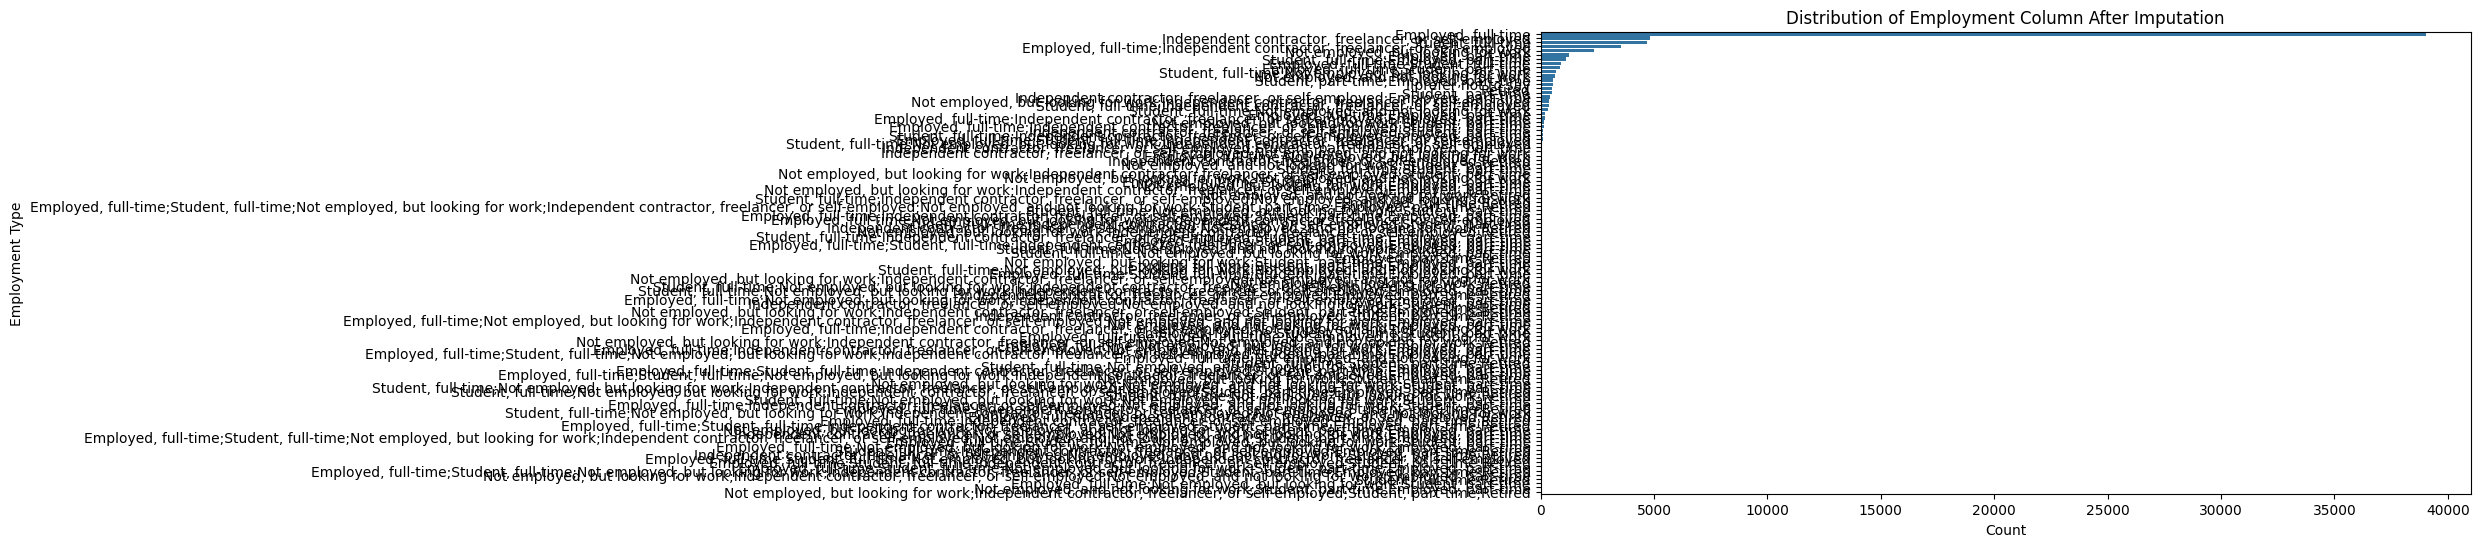

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"
df = pd.read_csv(url)

majority_value = df['Employment'].mode()[0]

df['Employment'] = df['Employment'].fillna(majority_value)

plt.figure(figsize=(14,7))


ax = sns.countplot(
    x=df['Employment'],
    order=df['Employment'].value_counts().index
)

plt.xticks(rotation=75)

plt.title("Distribution of Employment Column After Imputation")
plt.xlabel("Employment Type")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        str(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )
plt.tight_layout()
plt.show()

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
